In [4]:
%load_ext autoreload

In [5]:
import pymc as pm
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az
import pickle
import shutil
import numpy as np
import xarray as xr

%autoreload
import covid19_inference.covid19_inference as cov19
import utils
import plot
import model
import data_prep

# Input

In [4]:
# Set up basic configurations
name = "test_stay_at_home"  # Name of the experiment
pandemic_fatigue = "linear"  # Type of pandemic fatigue function
test = True  # Whether to run a test with fewer samples
single = True  # Whether to run a single model
run = False  # Whether to run the model or load the trace from a file

# Include weather parameters if required by giving any value
# If not required, set these to None
precipitation = None
temperature = None

# Generate all combinations of indicators
all_combinations = utils.indicator_combinations()

# Initialize a dictionary to store disease related data
disease_data = {}

# Set up directory for saving results
supDir_name = "results/" + name
utils.make_dir(supDir_name)

# Set up directory for saving figures
figdir_name = "figures/" + name
utils.make_dir(figdir_name)

# Copy the source code into the results directory for record keeping
shutil.copyfile("main.py", f"{supDir_name}/main.py")
shutil.copyfile("model.py", f"{supDir_name}/model.py")
shutil.copyfile("data_prep.py", f"{supDir_name}/data_prep.py")

# Load and prepare data
# Get out of home duration data
o_2020, o_base, dates_2020, dates_2022 = data_prep.get_out_of_home_duration()
dates = pd.to_datetime(dates_2020)

# Get kurzarbeit data
ka_df = data_prep.get_kurzarbeit(dates_2020)

# Get R_effective value for disease data
disease_data["R"] = data_prep.get_R(dates_2020)

# Get OWID data
owid = data_prep.get_owid()

# Get cases, ICU, and hospitalisations data from OWID
disease_data["C"] = data_prep.get_C(owid, dates_2020)
disease_data["ICU"] = data_prep.get_ICU(owid, dates_2020)
disease_data["H"] = data_prep.get_H(owid, dates_2020)

# Get stay at home orders data
stay_at_home_2020 = data_prep.get_S(dates_2020)

# If precipitation is included, get precipitation data
if precipitation is not None:
    precipitation = data_prep.get_delta_prcp(dates_2020, dates_2022)

# If temperature is included, get temperature data
if temperature is not None:
    temperature = {
        "average": data_prep.get_avg_T(dates_2020, dates_2022),
        "delta": data_prep.get_delta_T(dates_2020, dates_2022),
    }

if single:
    all_combinations = [['R', 'C']]

# Run model for each combination of indicators
for indicators in all_combinations:
    # Generate a tag for saving results
    tag = ""
    for indicator in indicators:
        tag += indicator + "_"
    tag = tag[:-1]

    # Set up directory for individual results
    dir_name = supDir_name + "/" + tag
    utils.make_dir(dir_name)

    # Create model
    inference_model = pm.Model()
    model.create_model(
        inference_model,
        o_base,
        o_2020,
        stay_at_home_2020,
        ka_df,
        indicators,
        disease_data,
        pandemic_fatigue,
        delta_prcp_in=precipitation,
        temperature_in=temperature,
    )

    if run:
        # Perform inference
        if test:
            trace = pm.sample(
                model=inference_model, draws=200, tune=200, cores=1, chains=4
            )
        else:
            trace = pm.sample(
                model=inference_model, draws=1000, tune=1000, cores=1, chains=4
            )
        with inference_model:
            pm.compute_log_likelihood(trace)

        # Save inference results
        ## trace
        path = f"{dir_name}/trace_{tag}.pickle"
        with open(path, "wb") as inference_file:
            pickle.dump(trace, inference_file)
        ## summary
        summary = az.summary(trace, round_to=2)
        path = f"{dir_name}/summary_{tag}.csv"
        summary.to_csv(path)
    else:
        trace = utils.load_trace(name, tag)

Directory  results/test_stay_at_home  already exists.
Directory  figures/test_stay_at_home  already exists.


INFO     [covid19_inference.covid19_inference.data_retrieval.retrieval] Successfully loaded OurWorldinData.csv.gz from /data.nst/eiftekhar/covid19/, skipping download.


Directory  results/test_stay_at_home/R_C  already exists.


INFO     [covid19_inference.covid19_inference.model.delay] Delaying cases
INFO     [covid19_inference.covid19_inference.model.delay] Delaying cases


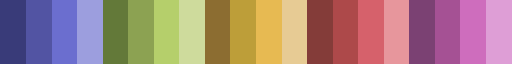

In [6]:
# colormap for plots
from matplotlib import colormaps
colormap = colormaps['tab20b']
colormap

In [6]:
# for the comparison section
all_indicator_combinations = utils.indicator_combinations()

# Comparison

## Pandemic fatigue

In [8]:
names = ["none", "sigmoid", "linear"]
# create empty dictionary with all indicator combinations as keys
trace_dict = {}
key_dict = {}

# generate dictionary of all traces
for name in names:
    key_dict[name] = []
    for indicators in all_indicator_combinations:
        indicator_tag = ""
        key = ""
        for indicator in indicators:
            indicator_tag += indicator + "_"
            key += indicator + "+"
        indicator_tag = indicator_tag[:-1]
        key = name[5:] + ", " + key[:-1]
        key_dict[name].append(key)

        trace_dict[key] = utils.load_trace(name, indicator_tag)

FileNotFoundError: [Errno 2] No such file or directory: 'results/linear/ICU/trace_ICU.pickle'

/data.nst/eiftekhar/mambaforge/envs/mobility/lib/python3.10/site-packages/arviz/stats/stats.py:803: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.7 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/data.nst/eiftekhar/mambaforge/envs/mobility/lib/python3.10/site-packages/arviz/stats/stats.py:803: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.7 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/data.nst/eiftekhar/

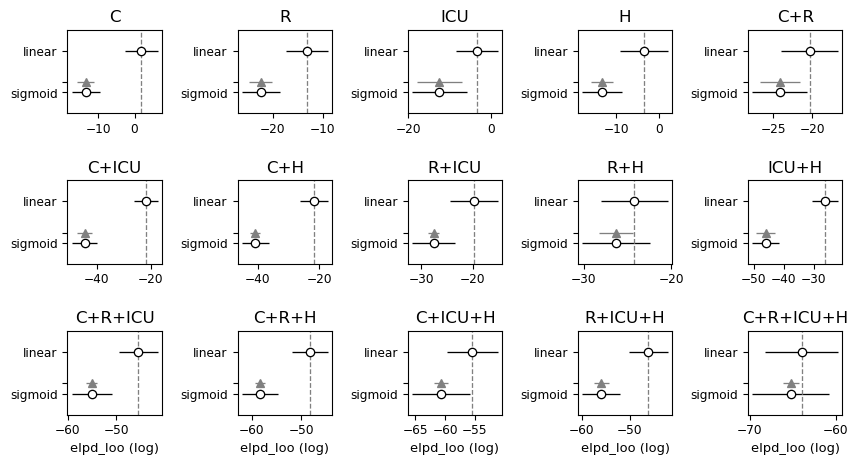

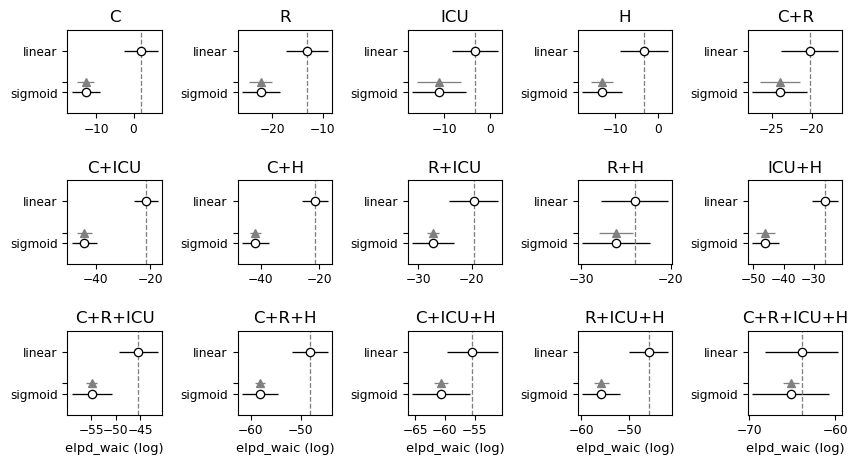

In [53]:
# compare plot with subplot for each indicator comibination, comparing the linear and sigmoid models
nrows = 3
ncols = 5
for ic in ['loo', 'waic']:
    fig, axs = plt.subplots(nrows, ncols, figsize=(10, 5))
    axs = axs.flatten()
    for i in range(len(all_indicator_combinations)):
        keys = [key_dict[name][i] for name in key_dict.keys()]
        # split key-string at ', '
        keys_separate = [key.split(', ') for key in keys]
        axs[i].set_title(keys_separate[0][1], fontsize=12)
        traces = {}
        for j in range(len(keys)):
            strings = keys_separate[j]
            key = keys[j]
            traces[strings[0]] = trace_dict[key]
        comparison = az.compare(traces, ic=ic)
        az.plot_compare(comparison, ax=axs[i], legend=False, title=False)
        axs[i].set_ylabel('')
        if 15 - i > ncols:
            axs[i].set_xlabel('')
    # add horizontal padding between subplots
    fig.subplots_adjust(wspace=0.8, hspace=0.5)
    # save figure
    fig.savefig(f'figures/model_selection/{ic}_pandemic_fatigue_pair.png', bbox_inches='tight')
    fig.savefig(f'figures/model_selection/{ic}_pandemic_fatigue_pair.pdf', bbox_inches='tight')

/data.nst/eiftekhar/mambaforge/envs/mobility/lib/python3.10/site-packages/arviz/stats/stats.py:803: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.7 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/data.nst/eiftekhar/mambaforge/envs/mobility/lib/python3.10/site-packages/arviz/stats/stats.py:803: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.7 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/data.nst/eiftekhar/

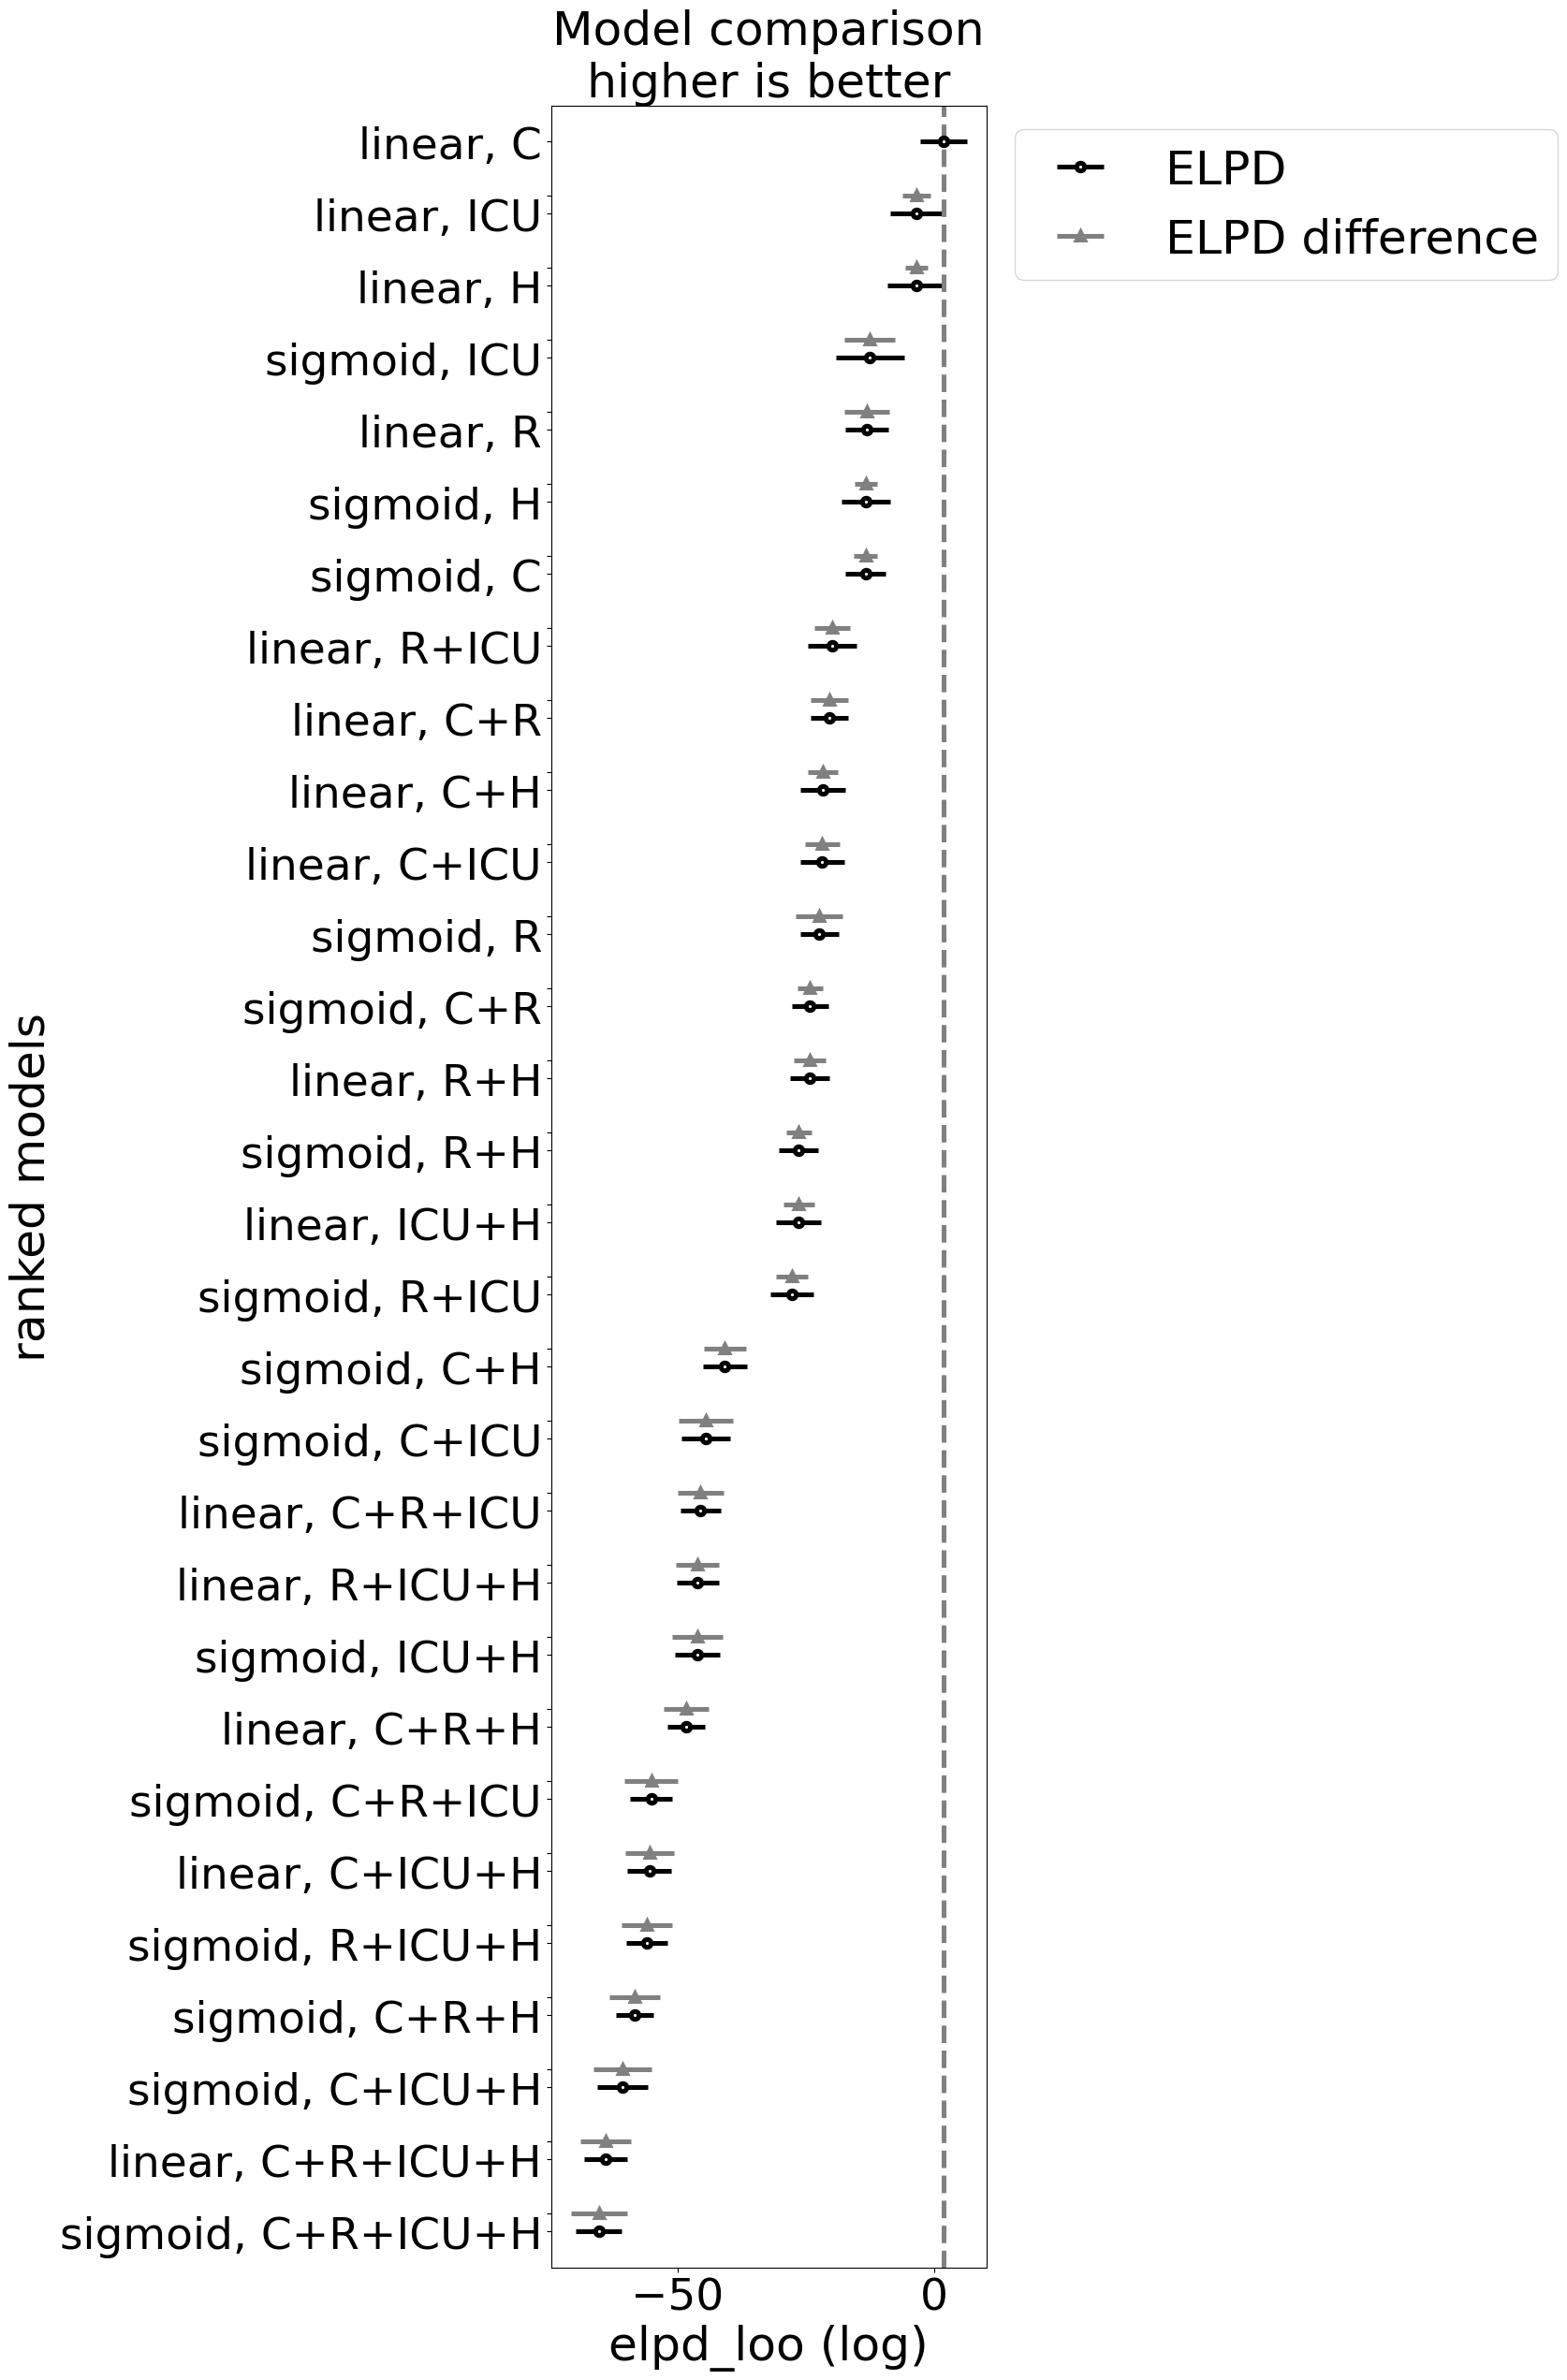

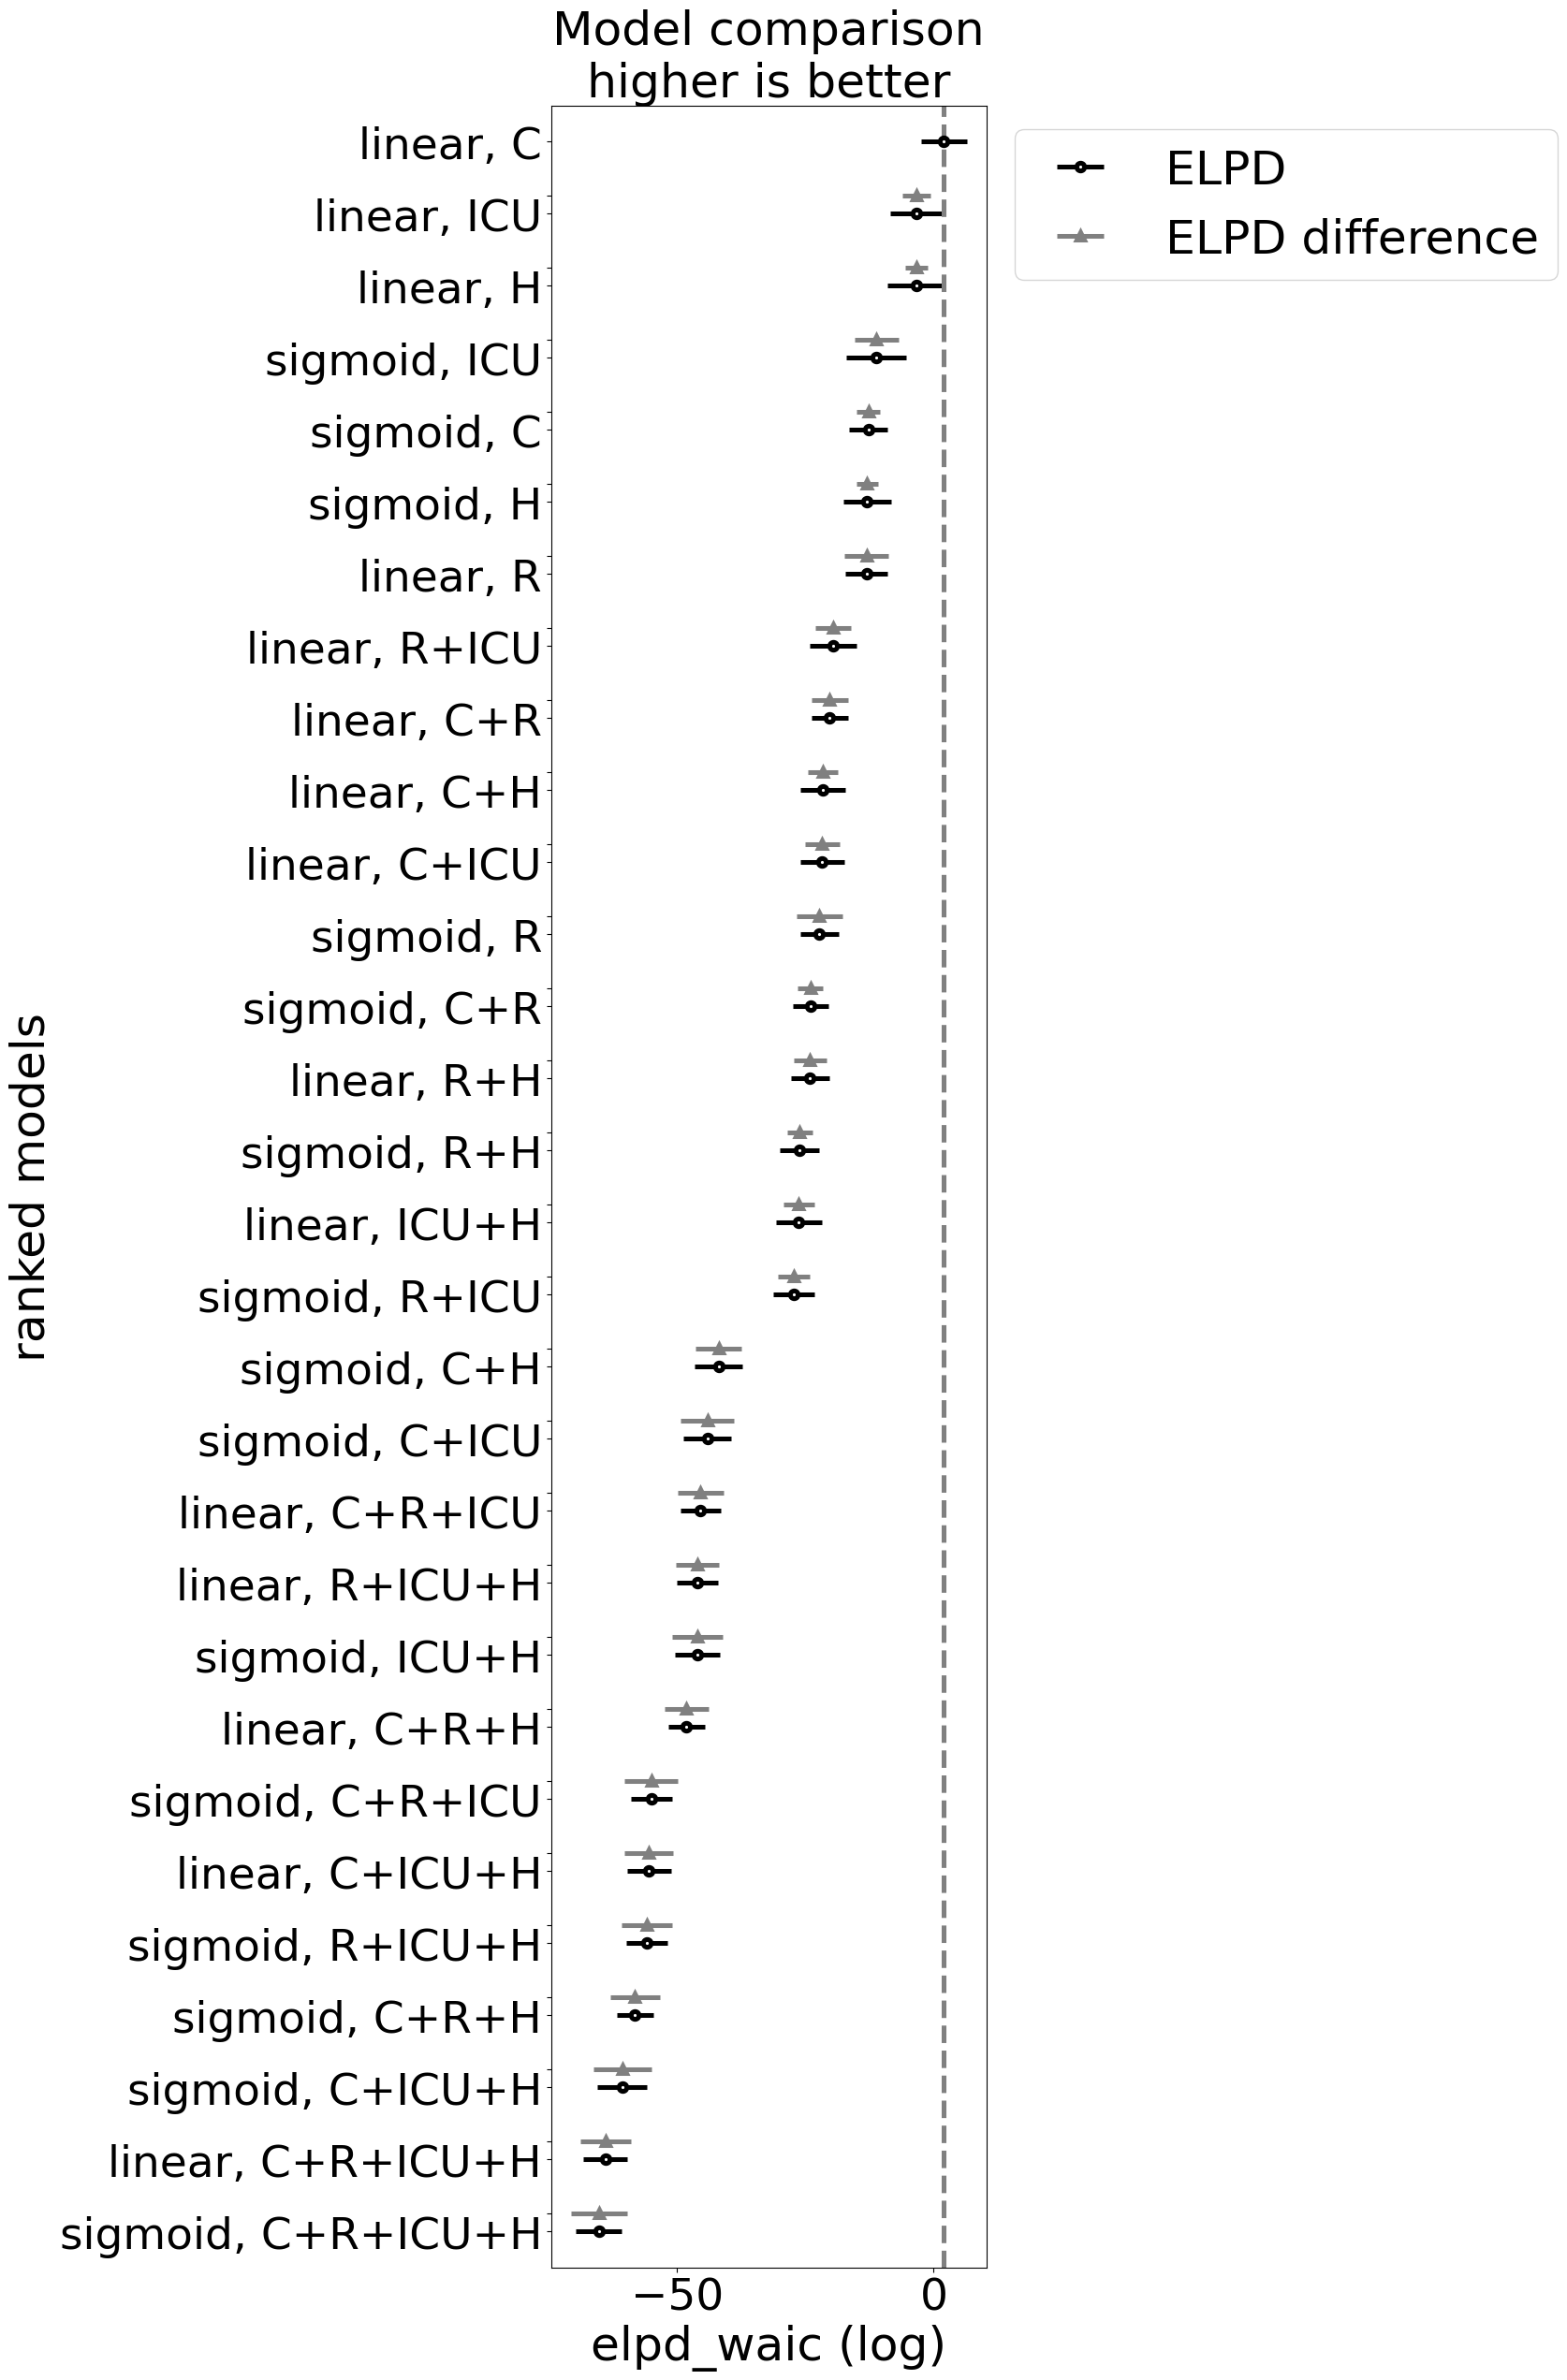

In [28]:
# model selection between all models in trace_dict
ics = ["loo", "waic"]
for ic in ics:
    comparison = az.compare(trace_dict, ic=ic)
    plot_result = az.plot_compare(comparison)
    # save plot
    plot_result.figure.savefig(f"figures/model_selection/{ic}_compare_pandemic_fatigue_all.png", bbox_inches="tight")

## Weather

In [10]:
names = [#"test_linear", 
         "precipitation", "temperature", "weather"]
labels = [#"no weather", 
          "precipitation", "temperature", "both"]
# create empty dictionary with all indicator combinations as keys
trace_dict = {}
key_dict = {}

# generate dictionary of all traces
for i in range(len(names)):
    name = names[i]
    label = labels[i]
    key_dict[label] = []
    for indicators in all_indicator_combinations:
        indicator_tag = ""
        key = ""
        for indicator in indicators:
            indicator_tag += indicator + "_"
            key += indicator + "+"
        indicator_tag = indicator_tag[:-1]
        key = label + ", " + key[:-1]
        key_dict[label].append(key)

        trace_dict[key] = utils.load_trace(name, indicator_tag)

/data.nst/eiftekhar/mambaforge/envs/mobility/lib/python3.10/site-packages/arviz/stats/stats.py:803: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.7 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/data.nst/eiftekhar/mambaforge/envs/mobility/lib/python3.10/site-packages/arviz/stats/stats.py:803: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.7 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/data.nst/eiftekhar/

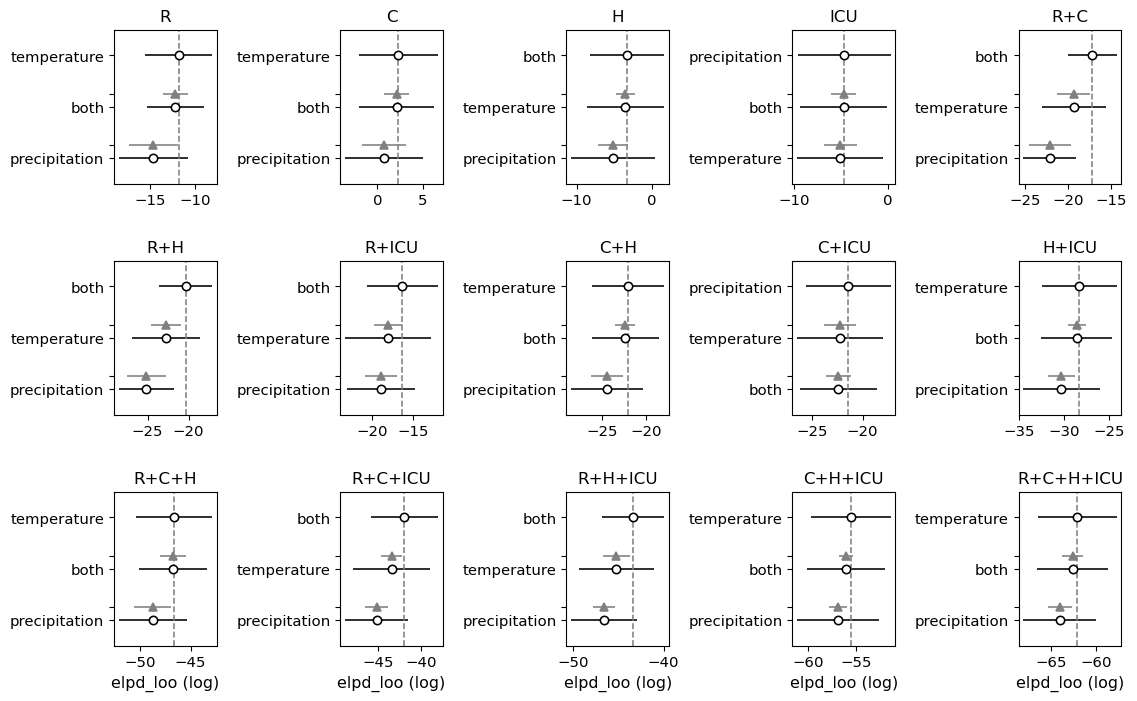

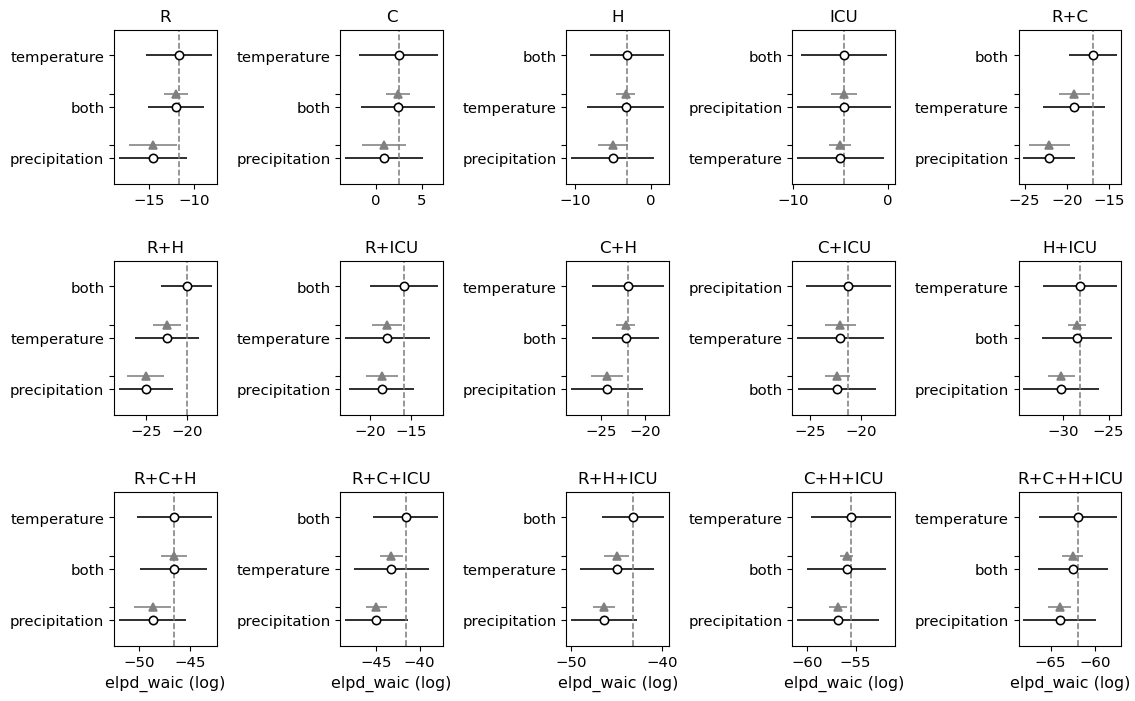

In [15]:
# compare plot with subplot for each indicator comibination, comparing the linear and sigmoid models
nrows = 3
ncols = 5
for ic in ['loo', 'waic']:
    fig, axs = plt.subplots(nrows, ncols, figsize=(13, 8))
    axs = axs.flatten()
    for i in range(len(all_indicator_combinations)):
        keys = [key_dict[name][i] for name in key_dict.keys()]
        # split key-string at ', '
        keys_separate = [key.split(', ') for key in keys]
        axs[i].set_title(keys_separate[0][1], fontsize=12)
        traces = {}
        for j in range(len(keys)):
            strings = keys_separate[j]
            key = keys[j]
            traces[strings[0]] = trace_dict[key]
        comparison = az.compare(traces, ic=ic)
        az.plot_compare(comparison, ax=axs[i], legend=False, title=False)
        axs[i].set_ylabel('')
        if 15 - i > ncols:
            axs[i].set_xlabel('')
    # add horizontal padding between subplots
    fig.subplots_adjust(wspace=1.2, hspace=0.5)
    # save figure
    fig.savefig(f'figures/model_selection/{ic}_weather.png', bbox_inches='tight')
    fig.savefig(f'figures/model_selection/{ic}_weather.pdf', bbox_inches='tight')